<a href="https://colab.research.google.com/github/chadiboudaher/mnist-pytorch/blob/main/mnist_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import torch
import torch
from torch import nn

# Import torchvision
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

# Import libraries for visualizing
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print(torch.__version__)
print(torchvision.__version__)

2.11.0+cpu
0.26.0+cpu


## 1. Getting the dataset

MNIST is a part of PyTorch torchvision datasets.

In [2]:
# Setup training data
train_data = datasets.MNIST(root="data",
                            train=True,
                            download=True,
                            transform=ToTensor(),
                            target_transform=None)

# Setup testing data
test_data = datasets.MNIST(root="root",
                           train=False,
                           download=True,
                           transform=ToTensor(),
                           target_transform=None)

100%|██████████| 9.91M/9.91M [00:00<00:00, 25.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 598kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 5.59MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.55MB/s]
100%|██████████| 9.91M/9.91M [00:00<00:00, 24.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 607kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 5.61MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.52MB/s]


In [3]:
len(train_data), len(test_data)

(60000, 10000)

## 2. Dataset Classes

Dataset classes represent the available/possible predicted output based on an input image.

In [4]:
class_names = train_data.classes
class_names

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

## 3. Check image shape

by checking the image shape we can see:
1. Number of color channels. 1 or 3 (RGB).
2. height.
3. Width.

These information help us recognize wether the size used is suitable (if data is not already processed) for learning.

In [5]:
image, label = train_data[0]
print(f"Image shape: {image.shape}")
print(f"Label shape: {label}")

Image shape: torch.Size([1, 28, 28])
Label shape: 5


### 3.1 Visualize our data

we can use matplotlib to see the visualize the dataset

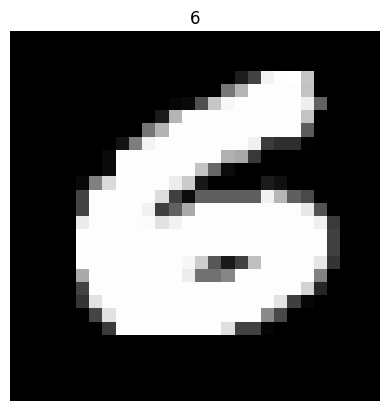

In [6]:
# Set seed
torch.manual_seed(42)

# Get Random image
random_image_number = torch.randint(low=0, high=len(train_data), size=[1]).item()
image, label = train_data[random_image_number]
# print(random_image_number)

# Plot random image
# plt.figure(figsize=(10, 10))
plt.title(label)
plt.imshow(image.squeeze(), cmap="grey")
plt.axis("off")
plt.show();

### 3.2 PLot Multiple Images

The purpose of this is just to check the data.

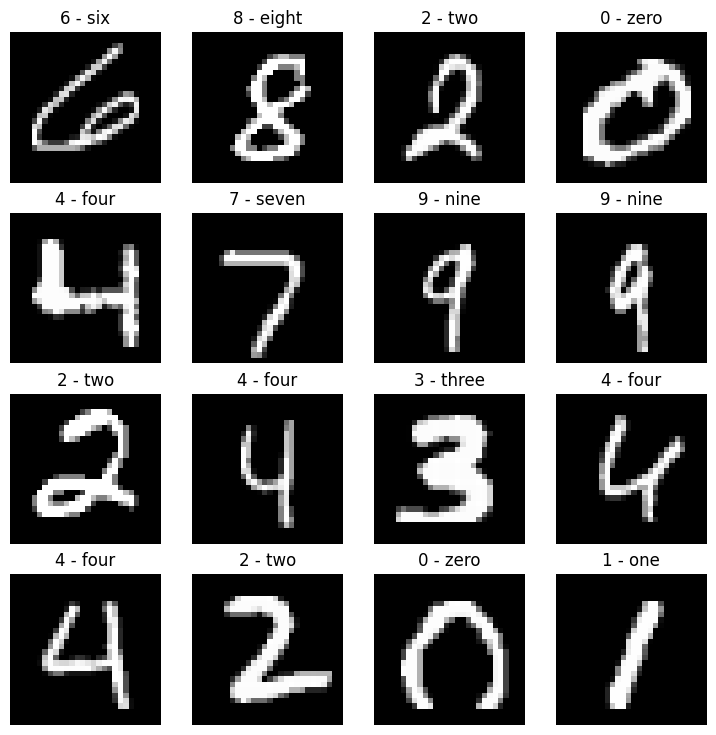

In [7]:
# Plot multiple images
fig = plt.figure(figsize=(9, 9))
rows, cols = 4, 4
for i in range(1, rows * cols + 1):
  random_index = torch.randint(low=0, high=len(train_data), size=[1]).item()
  image, label = train_data[random_index]
  fig.add_subplot(rows, cols, i)
  plt.imshow(image.squeeze(), cmap="grey")
  plt.title(class_names[label])
  plt.axis("off")

## 4. Prepare Dataloader

We want to turn our data into batches.

The advantages of this step:
1. More computationally efficient, our memory may not be able to look at 60,000 images in one hit.
2. It gives our neural network more chances to update its gradient per epochs.

In [8]:
from torch.utils.data import DataLoader

# Setup batch size
BATCH_SIZE = 32

# Turn Dataset into batches
train_dataloader = DataLoader(dataset=train_data,
                              batch_size=BATCH_SIZE,
                              shuffle=True)
test_dataloader = DataLoader(dataset=test_data,
                             batch_size=BATCH_SIZE,
                             shuffle=False)

# train_dataloader, test_dataloader
print(f"length of the train dataloader is : {len(train_dataloader)} batches of {BATCH_SIZE}..")
print(f"length of the test dataloader is : {len(test_dataloader)} batches of {BATCH_SIZE}..")

length of the train dataloader is : 1875 batches of 32..
length of the test dataloader is : 313 batches of 32..


### 4.1 Explore train and test dataloaders

In [9]:
train_features_batch, train_label_batch = next(iter(train_dataloader))
print(f"train dataloader feature's shape: {train_features_batch.shape}")
print(f"train dataloader label's shape: {train_label_batch.shape}")

train dataloader feature's shape: torch.Size([32, 1, 28, 28])
train dataloader label's shape: torch.Size([32])


## 5. Build a Baseline model

In [10]:
class MNISTv1(nn.Module):
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape, out_features=hidden_units),
        nn.Linear(in_features=hidden_units, out_features=output_shape)
    )

  def forward(self, x):
    return self.layer_stack(x)

In [11]:
torch.manual_seed(42)

# Setup model
model_0 = MNISTv1(
    input_shape=784,
    hidden_units=10,
    output_shape=len(class_names)
).to("cpu")

model_0

MNISTv1(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

## 6. Setup loss, optimizer and activation function

In [12]:
import requests
from pathlib import Path

# Download helper function from learn PyTorch repo
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exist, skipping download...")
else:
  print("Downloading helper functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

In [13]:
from helper_functions import accuracy_fn

# Setup loss function
loss_fn = nn.CrossEntropyLoss()

# Setup optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.1)

## 7. Create a function to time our experiments

In [14]:
from timeit import default_timer as timer
def print_train_time(start: float, end: float, device: torch.device = None):
  """
  Prints difference between start and end time.
  """
  total_time = start - end
  print(f"Train time on {device}: {total_time:.3f} seconds")
  return total_time

## 8. Create a training loop and training a model on batches of data

In [15]:
# import tqdm import tqdm
from tqdm.auto import tqdm

# Set the seed and start timer
torch.manual_seed(42)
train_time_start_on_cpu = timer()

# Set the number of epochs
epochs = 3

# Create a training and testing loop
for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n-----")

  train_loss = 0

  # Training
  for batch, (X, y) in enumerate(train_dataloader):

    # Set training mode
    model_0.train()

    # Forward Pass
    y_pred = model_0(X)

    # Calculate Loss
    loss = loss_fn(y_pred, y)
    train_loss += loss # accumulate the loss

    # optimizer zero grad
    optimizer.zero_grad()

    # Backward prop
    loss.backward()

    # Optimizer step
    optimizer.step()

    if batch % 400 == 0:
      print(f"Looked at {batch * len(X)} / {len(train_dataloader.dataset)} samples.")

  # Divide total train loss by length of train dataloader
  train_loss /= len(train_dataloader)


  # Testing
  test_loss, test_acc = 0, 0

  model_0.eval()
  with torch.inference_mode():
    for X_test, y_test in test_dataloader:

      # Forward Pass
      test_pred = model_0(X_test)

      # Calculate Loss
      test_loss += loss_fn(test_pred, y_test)

      # Calculate accuracy
      test_acc += accuracy_fn(y_test, test_pred.argmax(dim=1))

    # Calculate the test loss average
    test_loss /= len(test_dataloader)

    # Calculate accuracy average per batch
    test_acc /= len(test_dataloader)

  # Print out what is happening
  print(f"\nTrain loss: {train_loss:.4f} | Test loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")

# Calculate training time
train_time_end_on_cpu = timer()
total_train_time_model_0 = print_train_time(start=train_time_start_on_cpu,
                                          end=train_time_end_on_cpu,
                                          device=str(next(model_0.parameters()).device)
                                          )

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-----
Looked at 0 / 60000 samples.
Looked at 12800 / 60000 samples.
Looked at 25600 / 60000 samples.
Looked at 38400 / 60000 samples.
Looked at 51200 / 60000 samples.

Train loss: 0.4051 | Test loss: 0.2952 | Test Accuracy: 91.6733
Epoch: 1
-----
Looked at 0 / 60000 samples.
Looked at 12800 / 60000 samples.
Looked at 25600 / 60000 samples.
Looked at 38400 / 60000 samples.
Looked at 51200 / 60000 samples.

Train loss: 0.3084 | Test loss: 0.2862 | Test Accuracy: 91.9529
Epoch: 2
-----
Looked at 0 / 60000 samples.
Looked at 12800 / 60000 samples.
Looked at 25600 / 60000 samples.
Looked at 38400 / 60000 samples.
Looked at 51200 / 60000 samples.

Train loss: 0.2960 | Test loss: 0.2863 | Test Accuracy: 91.8930
Train time on cpu: -30.816 seconds


## 4. Make predictions and get model 0 results

In [19]:
torch.manual_seed(42)

def eval_model(model, data_loader, loss_fn, accuracy_fn):
  loss, acc = 0, 0

  model.eval()
  with torch.inference_mode():
    for X, y in tqdm(data_loader):
      y_pred = model(X)

      loss += loss_fn(y_pred, y).item()
      acc += accuracy_fn(y, y_pred.argmax(dim=1))

  loss /= len(data_loader)
  acc /= len(data_loader)

  return {
      "model_name": model.__class__.__name__,
      "model_loss": loss,
      "model_acc": acc,
  }

model_0_results = eval_model(model=model_0,
                            data_loader=test_dataloader,
                               loss_fn=loss_fn,
                               accuracy_fn=accuracy_fn)
model_0_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'MNISTv1',
 'model_loss': 0.28626732326175175,
 'model_acc': 91.8929712460064}